# Music Support Bot Notebook

## Setup

In [172]:
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

True

In [173]:
import operator
import sqlite3
import textwrap
from typing import Annotated, Literal

import requests
from IPython.display import Image, display
from langchain_community.utilities.sql_database import SQLDatabase
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field
from sqlalchemy import create_engine
from sqlalchemy.pool import StaticPool

## Setup tools

In [174]:
# Database setup
def get_engine_for_chinook_db():
    """Pull sql file, populate in-memory database, and create engine."""
    url = "https://raw.githubusercontent.com/lerocha/chinook-database/master/ChinookDatabase/DataSources/Chinook_Sqlite.sql"
    response = requests.get(url)
    sql_script = response.text

    connection = sqlite3.connect(":memory:", check_same_thread=False)
    connection.executescript(sql_script)
    return create_engine(
        "sqlite://",
        creator=lambda: connection,
        poolclass=StaticPool,
        connect_args={"check_same_thread": False},
    )


engine = get_engine_for_chinook_db()
db = SQLDatabase(engine)


def get_albums_by_artist(artist: str):
    """Get albums by an artist."""
    return db.run(
        f"""
        SELECT Album.Title, Artist.Name
        FROM Album
        JOIN Artist ON Album.ArtistId = Artist.ArtistId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


def get_tracks_by_artist(artist: str):
    """Get songs by an artist (or similar artists)."""
    return db.run(
        f"""
        SELECT Track.Name as SongName, Artist.Name as ArtistName
        FROM Album
        LEFT JOIN Artist ON Album.ArtistId = Artist.ArtistId
        LEFT JOIN Track ON Track.AlbumId = Album.AlbumId
        WHERE Artist.Name LIKE '%{artist}%';
        """,
        include_columns=True,
    )


def check_for_songs(song_title: str):
    """Check if a song exists by its name."""
    return db.run(
        f"""
        SELECT * FROM Track WHERE Name LIKE '%{song_title}%';
        """,
        include_columns=True,
    )

## Define state schema

In [184]:
class MusicQuery(BaseModel):
    artist: str | None = Field(default=None, description="The name of the artist")
    album: str | None = Field(default=None, description="The name of the album")
    song: str | None = Field(default=None, description="The name of the song")


class MessageClassification(BaseModel):
    intent: Literal["music_query", "customer_support", "other"]
    # urgency: Literal["low", "medium", "high", "critical"]
    # topic: str
    # summary: str

class MessageAgentState(BaseModel):
    # Raw message data
    message_content: str
    message_id: int
    sender_number: str

    # Classification result
    message_classification: MessageClassification | None = None

    # Music query
    music_query: MusicQuery | None = None
    search_results: Annotated[list[str], operator.add] = Field(default_factory=list)

    # # Generated content
    # draft_response: str | None

## Define Nodes

In [176]:
# Setup LLM
reasoning = {
    "effort": "low",  # 'low', 'medium', or 'high'
    "summary": None,  # 'detailed', 'auto', or None
}

llm = ChatOpenAI(model="gpt-5-nano", reasoning=reasoning)

In [185]:
# -----------------------------------------------------------------------------
# Classify intent
# -----------------------------------------------------------------------------

def classify_intent(state: MessageAgentState) -> MessageAgentState:
    """Use LLM to classify email intent and urgency, then route accordingly"""

    # Create structured LLM that returns MessageClassification
    structured_llm = llm.with_structured_output(MessageClassification)

    classification_prompt = textwrap.dedent(f"""
    Analyze this customer message and classify it:

    Message: {state.message_content}
    From: {state.sender_number}

    Provide a classification:
    - intent: either "music_query
    " or "customer_support" or "other"

    music_query: user is asking about music, artists, albums, or playlists
    customer_support: user is asking for help with their account, billing, or technical issues
    other: if the message doesn't fit either category or is too vague to classify
    """)

    # Get structured output from LLM
    message_classification = structured_llm.invoke(classification_prompt)
    state.message_classification = message_classification

    return state


def route_after_classification(
    state: MessageAgentState,
) -> Literal["customer_support_query", "parse_music_query", "__end__"]:
    if state.message_classification and state.message_classification.intent == "customer_support":
        return "customer_support_query"
    if state.message_classification and state.message_classification.intent == "music_query":
        return "parse_music_query"
    return END


# -----------------------------------------------------------------------------
# Parse music query
# -----------------------------------------------------------------------------

def parse_music_query(state: MessageAgentState) -> dict:
    structured_llm = llm.with_structured_output(MusicQuery)

    prompt = textwrap.dedent(
        f"""
    Analyze this customer message and extract music query information.

    Message: {state.message_content}

    Extract the following information if present:
    - artist: the name of the artist mentioned in the message, or None if not mentioned
    - album: the name of the album mentioned in the message, or None if not mentioned
    - song: the name of the song mentioned in the message, or None if not mentioned
    """
    )

    music_query = structured_llm.invoke(prompt)
    return {"music_query": music_query}


def search_album_by_artist(state: MessageAgentState) -> dict:
    print("Searching for albums by artist:", state.music_query.artist)
    if state.music_query and state.music_query.artist:
        albums = get_albums_by_artist(state.music_query.artist)
        print("Albums found:", albums)
        return {"search_results": [f"Albums by artist:\n{albums}"]}
    return {}


def search_tracks_by_artist(state: MessageAgentState) -> dict:
    print("Searching for tracks by artist:", state.music_query.artist)
    if state.music_query and state.music_query.artist:
        tracks = get_tracks_by_artist(state.music_query.artist)
        print("Tracks found:", tracks)
        return {"search_results": [f"Tracks by artist:\n{tracks}"]}
    return {}


def search_for_songs(state: MessageAgentState) -> dict:
    print("Searching for songs matching:", state.music_query.song)
    if state.music_query and state.music_query.song:
        songs = check_for_songs(state.music_query.song)
        print("Songs found:", songs)
        return {"search_results": [f"Song matches:\n{songs}"]}
    return {}


def route_after_music_query_classification(
    state: MessageAgentState,
) -> list[str] | Literal["__end__"]:
    if not state.music_query:
        return END

    next_nodes: list[str] = []

    if state.music_query.artist:
        next_nodes.append("search_album_by_artist")
        next_nodes.append("search_tracks_by_artist")

    if state.music_query.song:
        next_nodes.append("search_for_songs")

    if not next_nodes:
        return END

    return next_nodes


# -----------------------------------------------------------------------------
# Customer support query
# -----------------------------------------------------------------------------

def customer_support_query(state: MessageAgentState) -> MessageAgentState:
    """Handle customer support queries based on classified intent and topic"""
    print("Handling customer support query for:", state.message_content)
    return state

## Build the graph

In [186]:
# Memory
memory = InMemorySaver()


# Build graph
builder = StateGraph(MessageAgentState)


# Add nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("customer_support_query", customer_support_query)

builder.add_node("parse_music_query", parse_music_query)
builder.add_node("search_album_by_artist", search_album_by_artist)
builder.add_node("search_tracks_by_artist", search_tracks_by_artist)
builder.add_node("search_for_songs", search_for_songs)


# Add edges
builder.add_edge(START, "classify_intent")

builder.add_conditional_edges(
    "classify_intent",
    route_after_classification,
    [
        "customer_support_query",
        "parse_music_query",
        END,
    ],
)

builder.add_edge("customer_support_query", END)

builder.add_conditional_edges(
    "parse_music_query",
    route_after_music_query_classification,
    [
        "search_album_by_artist",
        "search_tracks_by_artist",
        "search_for_songs",
        END,
    ],
)
builder.add_edge("search_album_by_artist", END)
builder.add_edge("search_tracks_by_artist", END)
builder.add_edge("search_for_songs", END)

# Build graph
graph = builder.compile(checkpointer=memory)


message_id = 0

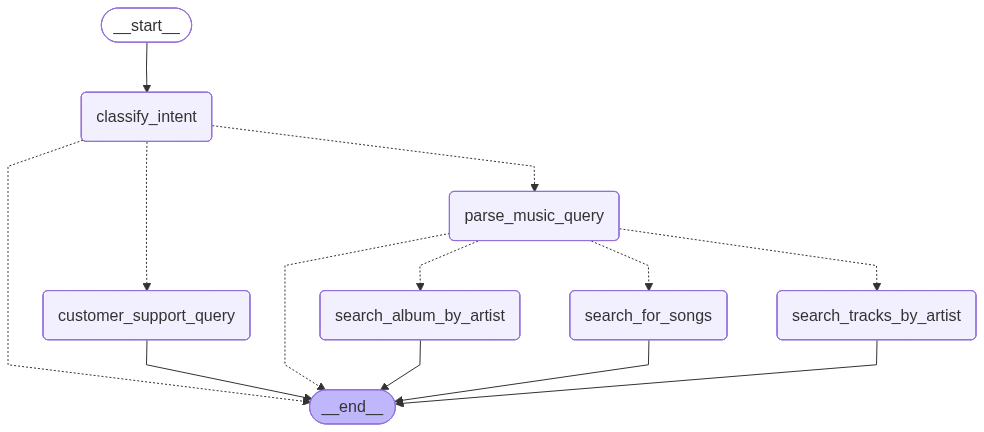

In [179]:
display(Image(graph.get_graph().draw_mermaid_png()))

## Test

In [ ]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="Tell me about the purple rain and prince",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

Searching for albums by artist: Prince
Searching for songs matching: Purple Rain
Searching for tracks by artist: Prince
Albums found: 
Tracks found: 
Songs found: 


In [168]:
print(result)

{'message_content': 'Tell me about the purple rain and prince', 'message_id': 2, 'sender_number': '555-123-1234', 'message_classification': MessageClassification(intent='music_query'), 'music_query': MusicQuery(artist='Prince', album='Purple Rain', song='Purple Rain'), 'search_results': ['Albums by artist:\n', 'Song matches:\n', 'Tracks by artist:\n']}


In [ ]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="I have a billing issue with my subscription",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)

Handling customer support query for: I have a billing issue with my subscription


In [187]:
# Simulate incoming message
message_id += 1

initial_message = MessageAgentState(
    message_content="How are you?",
    message_id=message_id,
    sender_number="555-123-1234",
)

config = {"configurable": {"thread_id": str(message_id)}}
result = graph.invoke(initial_message, config=config)